# Funnel Analysis Assessment

##  Import Libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

##  Load the Dataset


In [ ]:
df = pd.read_csv("/content/funnel_events_sample.csv")

##  Explore the Dataset


In [ ]:
df.head()

,user_id,step,timestamp
0,U158,visited_site,2026-07-20 03:39:00
1,U038,signup_started,2026-07-20 03:50:00
2,U117,visited_site,2026-07-20 04:09:00
3,U142,visited_site,2026-07-20 04:04:00
4,U126,visited_site,2026-07-20 03:43:00


In [ ]:
df.columns

Index(['user_id', 'step', 'timestamp'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    542 non-null    object
 1   step       542 non-null    object
 2   timestamp  542 non-null    object
dtypes: object(3)
memory usage: 12.8+ KB


In [ ]:
df.isnull().sum()

,0
user_id,0
step,0
timestamp,0


In [ ]:
len(df)

542

In [ ]:
df["user_id"].nunique()

200

In [ ]:
df["step"].unique()

array(['visited_site', 'signup_started', 'purchase_completed',
       'email_verified', 'details_filled'], dtype=object)

##  Calculate Unique Users
This section calculates the number of unique users who reached each stage of the funnel.

In [ ]:
stage_counts = (
    df.groupby("step")["user_id"]
      .nunique()
      .reset_index(name="unique_users")
)

stage_counts

,step,unique_users
0,details_filled,96
1,email_verified,52
2,purchase_completed,44
3,signup_started,150
4,visited_site,200


In [ ]:
stage_order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

stage_counts["step"] = pd.Categorical(
    stage_counts["step"],
    categories=stage_order,
    ordered=True
)

stage_counts = stage_counts.sort_values("step").reset_index(drop=True)

stage_counts

,step,unique_users
0,visited_site,200
1,signup_started,150
2,details_filled,96
3,email_verified,52
4,purchase_completed,44


In [ ]:
funnel = stage_counts.copy()

## Calculate Conversion Rate
The conversion rate measures the percentage of users who progressed from the previous funnel stage to the current stage.

In [ ]:
funnel["conversion_rate"] = (
    funnel["unique_users"] / funnel["unique_users"].shift(1) * 100
)

funnel.loc[0, "conversion_rate"] = 100

funnel["conversion_rate"] = funnel["conversion_rate"].round(2)

funnel

,step,unique_users,conversion_rate
0,visited_site,200,100.00
1,signup_started,150,75.00
2,details_filled,96,64.00
3,email_verified,52,54.17
4,purchase_completed,44,84.62


## Calculate Drop-off Rate
The drop-off rate represents the percentage of users who did not progress from the previous funnel stage to the current stage.

In [ ]:
funnel["drop_off_rate"] = 100 - funnel["conversion_rate"]

funnel.loc[0, "drop_off_rate"] = 0

funnel

,step,unique_users,conversion_rate,drop_off_rate
0,visited_site,200,100.00,0.00
1,signup_started,150,75.00,25.00
2,details_filled,96,64.00,36.00
3,email_verified,52,54.17,45.83
4,purchase_completed,44,84.62,15.38


## Identify the Biggest Drop-off
This section identifies the funnel stage with the highest drop-off rate to determine where users are most likely to abandon the journey.

In [ ]:
largest_drop = funnel.iloc[1:]["drop_off_rate"].idxmax()

print("Biggest Drop-off Stage:")
print(funnel.loc[largest_drop])

Biggest Drop-off Stage:
step               email_verified
unique_users                   52
conversion_rate             54.17
drop_off_rate               45.83
Name: 3, dtype: object


## Visualize the Funnel
The following visualization shows the number of unique users reaching each stage of the funnel.

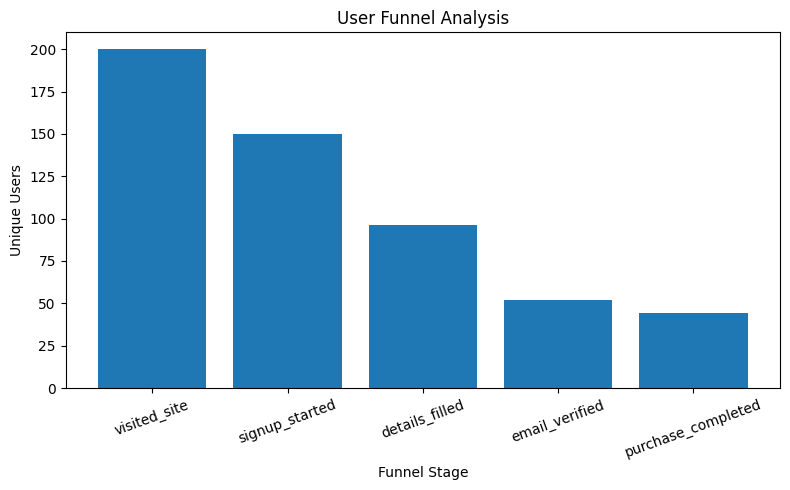

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(funnel["step"], funnel["unique_users"])

plt.title("User Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Analyze Average Time Between Stages
This analysis calculates the average time taken by users to move between consecutive funnel stages.

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
stage_order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

In [ ]:
stage_map = {stage: i for i, stage in enumerate(stage_order)}

df["stage_num"] = df["step"].map(stage_map)

In [ ]:
df = df.sort_values(["user_id", "timestamp"])

In [ ]:
df["next_step"] = df.groupby("user_id")["step"].shift(-1)
df["next_stage_num"] = df.groupby("user_id")["stage_num"].shift(-1)
df["next_time"] = df.groupby("user_id")["timestamp"].shift(-1)

In [ ]:
valid = df[df["next_stage_num"] == df["stage_num"] + 1].copy()

In [ ]:
valid["time_taken"] = (
    valid["next_time"] - valid["timestamp"]
).dt.total_seconds() / 60

In [ ]:
avg_time = (
    valid.groupby(["step", "next_step"])["time_taken"]
         .mean()
         .round(2)
         .reset_index()
)

avg_time

,step,next_step,time_taken
0,signup_started,details_filled,19.18
1,visited_site,signup_started,21.46


In [ ]:
print("Final Funnel Analysis")
display(funnel)

Final Funnel Analysis


,step,unique_users,conversion_rate,drop_off_rate
0,visited_site,200,100.00,0.00
1,signup_started,150,75.00,25.00
2,details_filled,96,64.00,36.00
3,email_verified,52,54.17,45.83
4,purchase_completed,44,84.62,15.38


Insights and Recommendations

## Dataset overview
Dataset contains 542 events from 200 unique users.
Funnel analysis identified the largest user loss during Email Verification.
Optimizing this stage could improve overall conversion.

## Business Insights

- The funnel starts with **200 users** visiting the site.
- The largest drop-off occurs between **Details Filled** and **Email Verified**, with a **45.83%** drop-off.
- This indicates that the email verification process may be causing friction.
- Improving the verification flow could significantly increase the overall purchase conversion rate.

## Recommendations

The highest user drop-off occurs during the transition from **Details Filled** to **Email Verified**. To reduce abandonment, simplify the verification process, enable one-click verification, send reminder emails, and clearly communicate why verification is required. These improvements can help increase user retention and overall conversion.

## Conclusion

This analysis identified user conversion at each stage of the funnel and highlighted the stage with the greatest user loss. The results show that optimizing the email verification step has the highest potential to improve the overall conversion rate.